## Experiment 2: One-Dimensional vs Two-Dimensional Image Kernels



Objective

The objective of this experiment is to compare two CUDA implementations of RGB-to-grayscale conversion that use different thread-indexing strategies:

1. A one-dimensional flattened indexing approach.
2. A two-dimensional row-and-column indexing approach.

The experiment is intended to understand how CUDA launch geometry affects code structure, indexing logic, readability, and performance while performing the same underlying computation.

The one-dimensional kernel will map each thread directly to a flattened pixel index:

$$
i = blockIdx.x \times blockDim.x + threadIdx.x
$$

The two-dimensional kernel will instead compute a row and column:

$$
row = blockIdx.y \times blockDim.y + threadIdx.y
$$

$$
col = blockIdx.x \times blockDim.x + threadIdx.x
$$

and convert them back into a flattened memory index:

$$
i = row \times W + col
$$

The comparison will focus on:

* Correctness of both implementations.
* Execution latency.
* Differences in launch geometry.
* Differences in bounds checking.
* Code clarity and indexing complexity.
* Whether using a multidimensional launch provides any practical performance advantage for this workload.

The purpose of the experiment is to demonstrate that multidimensional data does not inherently require multidimensional CUDA launch geometry, and that launch dimensions should be chosen based on clarity and suitability for the computation.


## Implementation

In [1]:
!nvidia-smi

Fri Sep 11 21:38:30 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install ninja

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.4/183.4 kB 16.8 MB/s eta 0:00:00


In [7]:
#importing libraries
import torch # standard torch operations
from torch.utils.cpp_extension import load_inline # loading inline C++/CUDA code
import pandas as pd # data manipulation
import time # timing operations
from matplotlib import pyplot as plt # plotting

print("Library Versions:")
print(f"torch: {torch.__version__}")
print(f"pandas: {pd.__version__}")


Library Versions:
torch: 2.11.0+cu128
pandas: 2.2.3


Implementing kernels using CHW Format for  Images

In [11]:
cpp_code = """
#include <torch/extension.h>

// 1D Kernel Launcher Signature
torch::Tensor rgb_to_grayscale_1d(
    torch::Tensor image // [C, H, W]
);

torch::Tensor rgb_to_grayscale_2d(
    torch::Tensor image // [C, H, W]
);

"""



cuda_code = """
#include <torch/extension.h>
#include <cstdint>
#include <c10/cuda/CUDAException.h>


// 1D Kernel Implementation
__global__ void rgb_to_grayscale_1d_kernel(
    const uint8_t* image, // [C, H, W]
    uint8_t* output, // [H, W]
    int width, // W
    int height // H
) {

    int idx = blockIdx.x * blockDim.x + threadIdx.x;
    if (idx < width * height) {
        float grayscale = 0.2989 * image[idx] + 0.5870 * image[idx + width * height] + 0.1140 * image[idx + 2 * width * height];
        // static casting to uint8_t
        output[idx] = static_cast<uint8_t>(grayscale);
    }
}

// 2D Kernel Implementation
__global__ void rgb_to_grayscale_2d_kernel(
    const uint8_t* image, // [C, H, W]
    uint8_t* output, // [H, W]
    int width, // W
    int height // H
) {

    int row = blockIdx.y * blockDim.y + threadIdx.y;
    int col = blockIdx.x * blockDim.x + threadIdx.x;
    if (row < height && col < width) {
        int pixel_index = row * width + col;
        float grayscale = 0.2989 * image[pixel_index] + 0.5870 * image[pixel_index + width * height] + 0.1140 * image[pixel_index + 2 * width * height];
        // static casting to uint8_t
        output[pixel_index] = static_cast<uint8_t>(grayscale);
    }
}
// 1D Kernel Launcher
torch::Tensor rgb_to_grayscale_1d(
    torch::Tensor image // [C, H, W]
) {
    // Step 1: Implement Checks before launching kernels
    // 1.1 Check if image is a tensor on the GPU
    TORCH_CHECK(image.device().is_cuda(), "image must be a CUDA tensor");
    // 1.2 Check if image is 3D tensor with CHW layout (3, H, W)
    TORCH_CHECK(image.dim() == 3 && image.size(0) == 3, "image must have 3 channels and three dimensions");
    // 1.3 Ensure the data type is uint8
    TORCH_CHECK(image.dtype() == torch::kUInt8, "image must have uint8 data type");
    // Get dimensions
    int width = image.size(2);
    int height = image.size(1);
    // Step 2: Create output tensor
    torch::Tensor output = torch::zeros({height, width}, image.options());
    // Step 3: Launch kernels
    // 3.1 Configure grid and block dimensions
    int block_size = 256;
    int grid_size = (width * height + block_size - 1) / block_size;
    // 3.2 Launch 1D kernel
    rgb_to_grayscale_1d_kernel<<<grid_size, block_size>>>(
        image.data_ptr<uint8_t>(),
        output.data_ptr<uint8_t>(),
        width, height
    );
    // 3.3 Kernel Launch Check
    C10_CUDA_KERNEL_LAUNCH_CHECK();
    // 3.4 Return output tensor
    return output;

}
// 2D Kernel Launcher
torch::Tensor rgb_to_grayscale_2d(
    torch::Tensor image // [C, H, W]
) {
    // Step 1: Implement Checks before launching kernels
    // 1.1 Check if image is a tensor on the GPU
    TORCH_CHECK(image.device().is_cuda(), "image must be a CUDA tensor");
    // 1.2 Check if image is 3D tensor with CHW layout (3, H, W)
    TORCH_CHECK(image.dim() == 3 && image.size(0) == 3, "image must have 3 channels and three dimensions");
    // 1.3 Ensure the data type is uint8
    TORCH_CHECK(image.dtype() == torch::kUInt8, "image must have uint8 data type");
    // Get dimensions
    int width = image.size(2);
    int height = image.size(1);
    // Step 2: Create output tensor
    torch::Tensor output = torch::zeros({height, width}, image.options());
    // Step 3: Launch kernels
    // 3.1 Configure grid and block dimensions
    dim3 block_size(16,16);
    dim3 grid_size((width + block_size.x - 1) / block_size.x, (height + block_size.y - 1) / block_size.y);
    // 3.2 Launch 1D kernel
    rgb_to_grayscale_2d_kernel<<<grid_size, block_size>>>(
        image.data_ptr<uint8_t>(),
        output.data_ptr<uint8_t>(),
        width, height
    );
    // 3.3 Kernel Launch Check
    C10_CUDA_KERNEL_LAUNCH_CHECK();
    // 3.4 Return output tensor
    return output;
}
"""

In [12]:
rgb_to_grayscale = load_inline(
    name="rgb_to_grayscale_v2",
    cpp_sources=cpp_code,
    cuda_sources=cuda_code,
    functions=["rgb_to_grayscale_1d", "rgb_to_grayscale_2d"],
    extra_cuda_cflags=["-O3"],
    extra_cflags=["-O3"],
    verbose=True,
)


In [14]:
def correctness_check(input_image):
    # Convert input image to uint8
    input_image = input_image.to(torch.uint8)
    # Push the image to the GPU
    input_image = input_image.cuda()
    # Get dimensions
    width = input_image.size(2)
    height = input_image.size(1)
    # Get channels
    channels = input_image.size(0)
    # Get the output of the 1D kernel
    output_1d = rgb_to_grayscale.rgb_to_grayscale_1d(input_image)
    # Get the output of the 2D kernel
    output_2d = rgb_to_grayscale.rgb_to_grayscale_2d(input_image)
    # Check if the outputs are the same
    return True if torch.allclose(output_1d, output_2d) else False
    

# Test the correctness of the kernels
test_image = torch.randint(0, 256, (3, 256, 256), dtype=torch.uint8)
correctness_check(test_image)


True

In [15]:
def kernel_exec_latency(input_image, warmup_steps=10, repeat_steps=10):
    # Convert input image to uint8
    input_image = input_image.to(torch.uint8)
    # Push the image to the GPU
    input_image = input_image.cuda()
    # Get dimensions
    width = input_image.size(2)
    height = input_image.size(1)
    # Get channels
    channels = input_image.size(0)

    # Warmup
    for _ in range(warmup_steps):
        rgb_to_grayscale.rgb_to_grayscale_1d(input_image)
        rgb_to_grayscale.rgb_to_grayscale_2d(input_image)
    # Use CUDA events to measure the latency
    start = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)
    # Get the output of the 1D kernel
    for _ in range(repeat_steps):
        start.record()
        output_1d = rgb_to_grayscale.rgb_to_grayscale_1d(input_image)
        end.record()
        torch.cuda.synchronize()
        latency_1d = start.elapsed_time(end)
    # Get the output of the 2D kernel
    for _ in range(repeat_steps):
        start.record()
        output_2d = rgb_to_grayscale.rgb_to_grayscale_2d(input_image)
        end.record()
        torch.cuda.synchronize()
        latency_2d = start.elapsed_time(end)
    # Return the latency
    print(f"Average Latency for 1D Kernel: {latency_1d / repeat_steps} ms")
    print(f"Average Latency for 2D Kernel: {latency_2d / repeat_steps} ms")
    return latency_1d/repeat_steps, latency_2d/repeat_steps


Average Latency for 1D Kernel: 0.0028704000636935235 ms
Average Latency for 2D Kernel: 0.003094400092959404 ms
Average Latency for 1D Kernel: 0.006140799820423126 ms
Average Latency for 2D Kernel: 0.006153599917888641 ms
Average Latency for 1D Kernel: 0.019897599518299103 ms
Average Latency for 2D Kernel: 0.01979839950799942 ms
Average Latency for 1D Kernel: 0.07346879839897155 ms
Average Latency for 2D Kernel: 0.07419520020484924 ms


Text(0.5, 1.0, 'Latency of 1D and 2D Image Kernels')

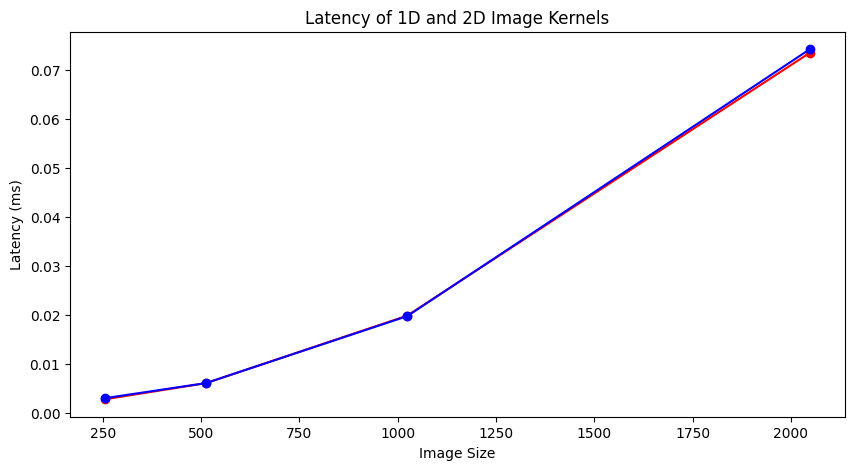

In [19]:
latencies = {'1D Kernel': [], '2D Kernel': []}
image_sizes = [256, 512, 1024, 2048]
for i in image_sizes:
    test_image = torch.randint(0, 256, (3, i, i), dtype=torch.uint8)
    latency_1d, latency_2d = kernel_exec_latency(test_image)
    latencies['1D Kernel'].append(latency_1d)
    latencies['2D Kernel'].append(latency_2d)


# Plot the latencies of 1D and 2D kernels along different image sizes
plt.figure(figsize=(10, 5))
plt.plot(image_sizes, latencies['1D Kernel'], label='1D Kernel',color='red',marker='o')
plt.plot(image_sizes, latencies['2D Kernel'], label='2D Kernel',color='blue',marker='o')
plt.xlabel('Image Size')
plt.ylabel('Latency (ms)')
plt.title('Latency of 1D and 2D Image Kernels')

## Observations

The 1D and 2D grayscale CUDA kernels show nearly identical latency across all tested image sizes. As image size increases, latency rises similarly for both implementations, with no meaningful performance advantage from using 2D indexing. This suggests that, for this simple pixel-wise workload, launch geometry is mainly a matter of indexing convenience and code clarity rather than performance. The 1D flattened version is slightly simpler, while the 2D version maps more naturally to image coordinates.